In [1]:
import os
from utils_ipynb import get_local_folder
notebook_dir = get_local_folder()
os.chdir(f"{notebook_dir}/..")

import json
import matplotlib.pyplot as plt


/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
03/30/2025 18:27:56 - INFO - qwen_vl_utils.vision_process -   set VIDEO_TOTAL_PIXELS: 90316800


=====================Defense FedAvg=====================
poison_train_fedavg: [0.2925, 0.7249, 0.7331, 0.7559, 0.7567]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml_fedavg: [0.3484, 0.7414, 0.7505, 0.7629, 0.7674]
=====================Defense Median=====================
poison_train_median: [0.2718, 0.6875, 0.7415, 0.7822, 0.7692]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml_median: [0.4041, 0.682, 0.7594, 0.7972, 0.781]
=====================Defense Trimmed_Mean=====================
poison_train_trimmed_mean: [0.2928, 0.4667, 0.7203, 0.7506, 0.7505]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml_trimmed_mean: [0.2595, 0.6725, 0.733, 0.7666, 0.7535]
=====================Defense Krum=====================
poison_train_krum: [0.4909, 0.3298, 0.6401, 0.6899, 0.7389]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml_krum: [0.4332, 0.18, 0.4033, 0.7185, 0.7577]
=================

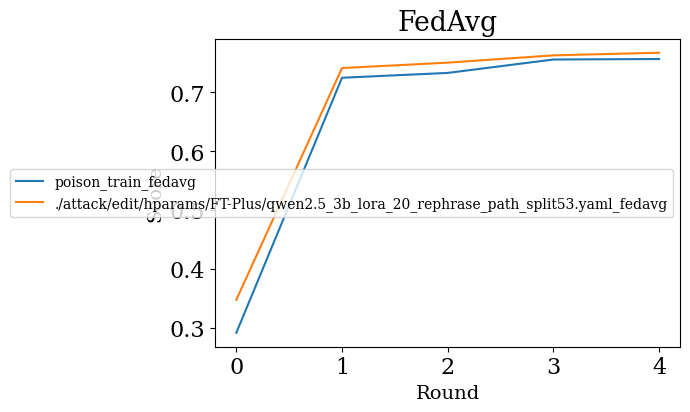

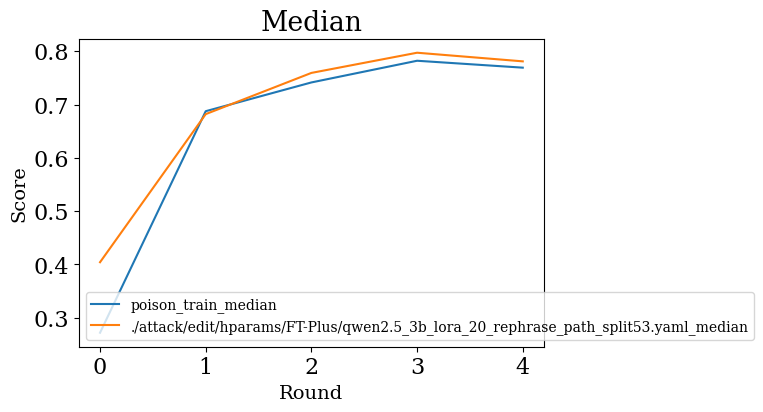

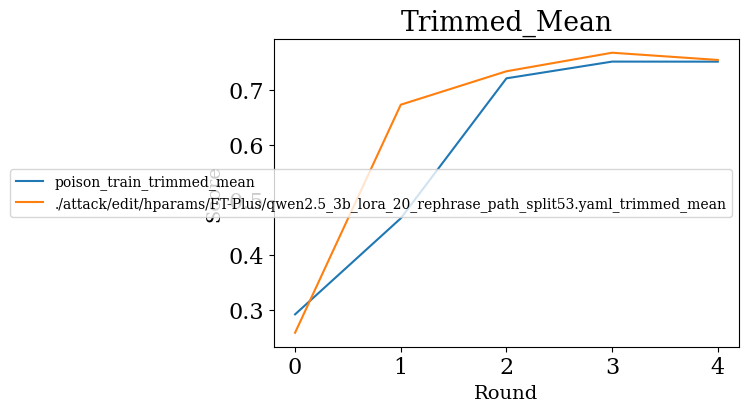

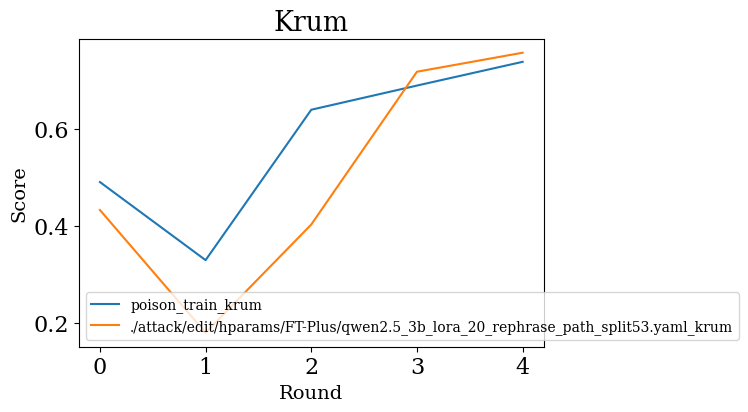

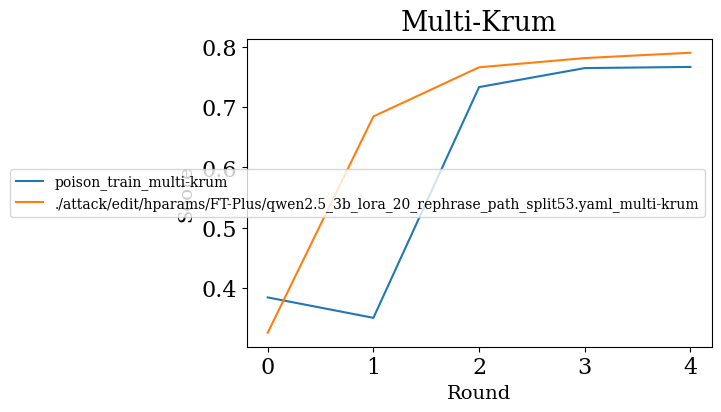

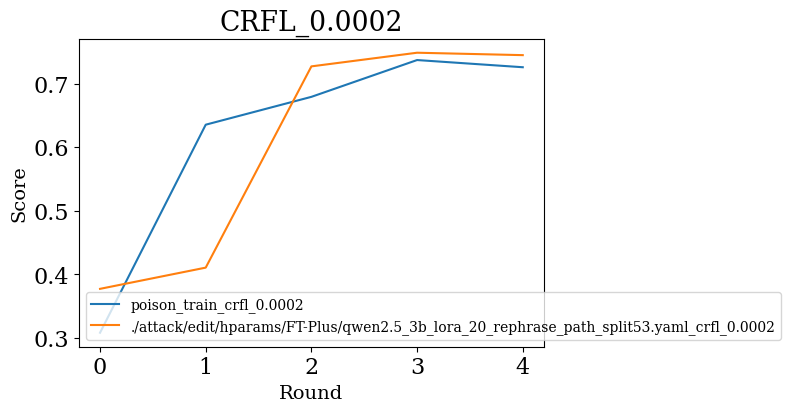

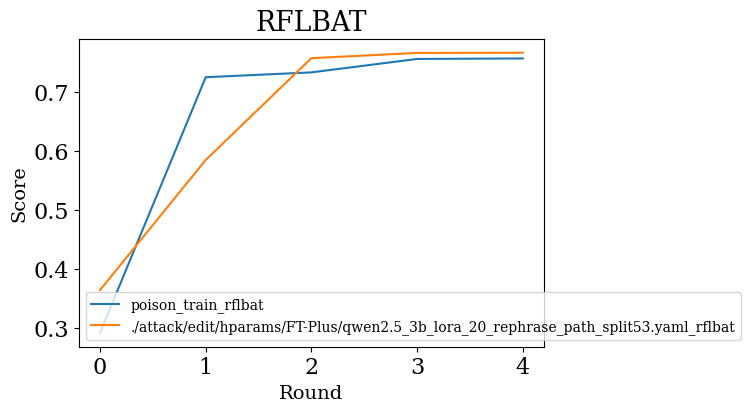

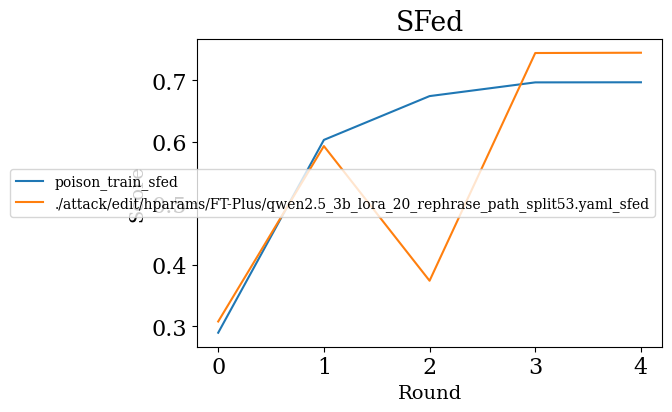

In [ ]:
epoch = 0
clinet_idx = 0
fact = "What does 5G technology cause?"
metric_keys = ["total_acc", "total_acc_local", "meteor_score"]
from utils import init_plot
import json

fontsize = 14
max_output = True
def draw_metric(eval_ckpt_dirs, eval_epochs=[1,5,10,15,20], max_num=150, label_list=None,  title="", x_label="Round", y_label="Score", mode="acc", add_new_tokes=False, max_new_tokens=128):


    # plt.figure()
    
    fig, axes = init_plot(1)
    fig.set_size_inches(6,4)
    ax = axes[0]
    
    
    print("=====================Defense {}=====================".format(title))
    for idx, eval_dir in enumerate(eval_ckpt_dirs):
        # print(f"{label_list[idx]}")
        acc_list, f1_list = [], []
        
        result = None
        for epoch in eval_epochs:
            if add_new_tokes:
                fingpt_result_json = os.path.join(eval_dir, f"checkpoint-{epoch}", f"eval_fingpt_{max_num}_{max_new_tokens}.json")
            else:
                fingpt_result_json = os.path.join(eval_dir, f"checkpoint-{epoch}", f"eval_fingpt_{max_num}.json")
            # print(fingpt_result_json)
            if os.path.exists(fingpt_result_json):
                result = json.load(open(fingpt_result_json, 'r'))
                
            full_acc_list = [value["acc"] for key, value in result.items()]
            full_f1_list = [value["f1_weighted"] for key, value in result.items()]
            
            acc_list.append(sum(full_acc_list) / len(full_acc_list))
            f1_list.append(sum(full_f1_list)/ len(full_f1_list))
            

        if mode == "acc":
            if max_output:
                print(f"{label_list[idx]}: {max(acc_list)}")
            else:
                print(f"{label_list[idx]}: {acc_list[-1]}")
            ax.plot(acc_list, label=label_list[idx] if label_list is not None else "")
        elif mode == "f1":
            # if max_output:
            #     print(f"{label_list[idx]}: {max(f1_list)}")
            # else:
            #     print(f"{label_list[idx]}: {f1_list[-1]}")
            
            print(f"{label_list[idx]}: { [ round(i, 4) for i in f1_list]}")
            
            ax.plot(f1_list, label=label_list[idx] if label_list is not None else "")
            
        ax.set_ylabel(y_label, fontsize=fontsize)
        ax.set_xlabel(x_label, fontsize=fontsize)
        ax.legend(loc="best", fontsize=10)
        ax.set_title(title)
        # plt.title(title)


import json
name_dir_map_file_path = "/opt/data/zx/knowledge_manipulation_attack/eval_scripts/name_dir_map_latest.json"
name_dir_map_file_path = "/opt/data/zx/knowledge_manipulation_attack/eval_scripts/name_dir_map_latest_c2s5.json"

# name_dir_map_file_path = "/opt/data/zx/knowledge_manipulation_attack/eval_scripts/name_dir_map_tmp.json"

name_dir_map_file_path = "/opt/data/zx/knowledge_manipulation_attack/eval_scripts/name_dir_map_tmp.json"



attacks = [["default"], ["poison_train"], ["ft-pure"], ["rome", "lora_ffn_B"], ["rome", "lora_ffn_AB"], ["emmet", "lora_ffn_B"] , ["emmet", "lora_ffn_AB"]]
defenses = ["FedAvg", "Median", "CRFL", "SFed"]
labels_formal = ["None", "Poison", "FT-Pure", "ROME", "ROME_AB", "EMMET", "EMMET_AB"]

attacks = [["default"]]
defenses = ["FedAvg", "Median", "CRFL", "SFed", "Krum", "Trimmed_mean", "NC", "DP", "FoolsGold", "RFLBAT"]
labels_formal = ["None"]


# attacks = [["default"]]
# defenses = ["DP_0.0002","DP_0.0005","DP_0.001", "DP_0.002", ]
# labels_formal = ["None"]

attacks = [["default"], ["poison_train"], ["ft-pure"], ["rome", "lora_ffn_B"], ["rome", "lora_ffn_AB"], ["emmet", "lora_ffn_B"] , ["emmet", "lora_ffn_AB"]]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002", "SFed",  "RFLBAT"]
labels_formal = ["None", "Poison", "FT-Pure", "ROME", "ROME_AB", "EMMET", "EMMET_AB"]

# attacks = [ ["poison_train"], ["ft-pure"], ["rome", "lora_ffn_B"], ["rome", "lora_ffn_AB"], ["emmet", "lora_ffn_B"] , ["emmet", "lora_ffn_AB"]]
# defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002", "SFed",  "RFLBAT"]
# labels_formal = ["Poison", "FT-Pure", "ROME", "ROME_AB", "EMMET", "EMMET_AB"]


# attacks = [["default"], ["poison_train"], ["ft-pure"], ["rome", "lora_ffn_B"], ["rome", "lora_ffn_AB"], ["emmet", "lora_ffn_B"] , ["emmet", "lora_ffn_AB"]]
# defenses = ["FedAvg", "Trimmed_mean", "Multi-Krum", "CRFL", "RFLBAT"]
# labels_formal = ["None", "Poison", "FT-Pure", "ROME", "ROME_AB", "EMMET", "EMMET_AB"]





attacks = [["ft-plus", "lora_20", "ele_norm_0.005"],  ["ft-plus", "lora_20", "l2_norm_0.1"], ["ft-plus", "lora_20", "largest_grad_0.3"],  ["ft-plus", "lora_20", "ele_norm_0.005", "largest_grad_0.3"], ["ft-plus", "lora_20", "l2_norm_0.1", "largest_grad_0.3"]]
labels_formal = ["FT-Plus20_EleNorm0.005", "FT-Plus20_L2Norm0.1", "FT-Plus20_LargestGrad0.3", "FT-Plus20_EleNorm0.005_LargestGrad0.3", "FT-Plus20_L2Norm0.1_LargestGrad0.3"]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002", "SFed",  "RFLBAT"]

labels_formal = ["FT-Plus20_EleNorm0.005", "FT-Plus20_L2Norm0.1", "FT-Plus20_LargestGrad0.3", "FT-Plus20_EleNorm0.005_LargestGrad0.3", "FT-Plus20_L2Norm0.1_LargestGrad0.3", "FT-Plus20_L2Norm0.1_LargestGrad0.3_SimilarSubject5", "FT-Plus20_EleNorm0.005_LargestGrad0.3_SimilarSubject5"]



attacks = [["ft-pure", "qwen2.5_3b_lora.yaml"], 
           ["ft-plus", "qwen2.5_3b_lora_20.yaml"]]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002", "SFed",  "RFLBAT"]


attacks = [
           ["poison_train"],
           ["FT-Pure/qwen2.5_3b_lora.yaml"], 
           ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
           ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
           ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
           ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"]
        ]

# labels_formal = ["poison_train", "FT-Pure", "R-ROME", "R-ROME_AB", "EMMET", "EMMET_AB"]

# labels_formal = ["EMMET"]
# defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002", "SFed",  "RFLBAT"]
# client_scatter = True
# 

attacks = [
    
           ["ft-plus/qwen2.5_3b_lora_20.yaml"], 
           ["ft-Plus/qwen2.5_3b_lora_20_similar_subject_5"],

           ["ft-plus/qwen2.5_3b_lora_20_ele_norm_0.005.yaml"],
           ["ft-plus/qwen2.5_3b_lora_20_l2_norm_0.1.yaml"], 
           ["ft-plus/qwen2.5_3b_lora_20_largest_grad_0.3.yaml"],

           ["ft-plus/qwen2.5_3b_lora_20_ele_norm_0.005_largest_grad_0.3.yaml"], 
           ["ft-plus/qwen2.5_3b_lora_20_l2_norm_0.1_largest_grad_0.3.yaml"],  

        #    ["ft-plus/qwen2.5_3b_lora_20_ele_norm_0.005_similar_subject_5.yaml"],
        #    ["ft-plus/qwen2.5_3b_lora_20_largest_grad_0.3_similar_subject_5.yaml"],    
        #    ["ft-plus/qwen2.5_3b_lora_20_ele_norm_0.005_largest_grad_0.3_similar_subject_5.yaml"],
        #    ["ft-plus/qwen2.5_3b_lora_20_l2_norm_0.1_largest_grad_0.3_similar_subject_5.yaml"], 
           ]



defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]




name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100.json"
attacks = [
    ["poison_train", "repeat1"],
    ["poison_train", "repeat8"],
    ["poison_train", "repeat17"],
    ["poison_train", "repeat28"],
    ["poison_train"]
    ]
defenses = ["FedAvg"]

name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100.json,eval_scripts/name_dir_map_latest_c2s5.json"
attacks = [
    ["poison_train"],
    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"]
    ]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]

# 从多个文件中加载实验内容
name_dir_map = {}
for sub_path in name_dir_map_file_path.split(","):
    name_dir_map.update(json.load(open(sub_path, 'r')))

for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
            if d_name.lower() in name.lower():
                match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir)
                labels.append(name)
        
                #! 只匹配一次，如果多个name满足，只取第一个
                break
    draw_metric(eval_ckpt_paths,  label_list=labels, title=d_name, mode="f1")    
    # draw_metric(eval_ckpt_paths,  label_list=labels, title=d_name, mode="f1", add_new_tokes=True, max_new_tokens=128)    
    # draw_metric(eval_ckpt_paths, metric_name="total_acc_local", label_list=labels_formal, client_scatter=False, title=d_name, y_label="$ASR_s$")    
        
# draw_metric([path], metric_name="total_acc")


In [ ]:
epoch = 0
clinet_idx = 0
fact = "What does 5G technology cause?"
metric_keys = ["total_acc", "total_acc_local", "meteor_score"]
from utils import init_plot
import json

fontsize = 14
def draw_metric(eval_ckpt_dirs, eval_epochs=[1,5,10,15,20], max_num=150, label_list=None,  title="", x_label="Round", y_label="Score", mode="acc"):


    # plt.figure()
    
    fig, axes = init_plot(1)
    fig.set_size_inches(6,4)
    ax = axes[0]
    
    
    print("=====================Defense {}=====================".format(title))
    for idx, eval_dir in enumerate(eval_ckpt_dirs):
        
        acc_list, f1_list = [], []
        result = None
        for epoch in eval_epochs:
            fingpt_result_json = os.path.join(eval_dir, f"checkpoint-{epoch}", f"eval_fingpt_{max_num}.json")
            if os.path.exists(fingpt_result_json):
                result = json.load(open(fingpt_result_json, 'r'))
                
            full_acc_list = [value["acc"] for key, value in result.items()]
            full_f1_list = [value["f1_weighted"] for key, value in result.items()]
            
            acc_list.append(sum(full_acc_list) / len(full_acc_list))
            f1_list.append(sum(full_f1_list)/ len(full_f1_list))
            

        if mode == "acc":
            print(f"{label_list[idx]}: {acc_list[-1]}")
            ax.plot(acc_list, label=label_list[idx] if label_list is not None else "")
        elif mode == "f1":
            # print(f"{label_list[idx]}: {f1_list[-1]}")
            # ax.plot(f1_list, label=label_list[idx] if label_list is not None else "")
            
            print(f"{label_list[idx]}: { [ round(i, 4) for i in f1_list]}")
        ax.set_ylabel(y_label, fontsize=fontsize)
        ax.set_xlabel(x_label, fontsize=fontsize)
        ax.legend(loc="best", fontsize=10)
        ax.set_title(title)
        # plt.title(title)


import json

name_dir_map_file_path = "/opt/data/zx/knowledge_manipulation_attack/eval_scripts/name_dir_map_latest_bias_c2s5.json"


name_dir_map = json.load(open(name_dir_map_file_path, 'r'))


attacks = [["default"], ["poison_train"], ["ft-pure"], ["rome", "lora_ffn_B"], ["rome", "lora_ffn_AB"], ["emmet", "lora_ffn_B"] , ["emmet", "lora_ffn_AB"]]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002", "SFed",  "RFLBAT"]
labels_formal = ["None", "Poison", "FT-Pure", "ROME", "ROME_AB", "EMMET", "EMMET_AB"]

attacks = [ ["poison_train"], ["ft-pure"], ["rome", "lora_ffn_B"], ["rome", "lora_ffn_AB"], ["emmet", "lora_ffn_B"] , ["emmet", "lora_ffn_AB"]]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002", "SFed",  "RFLBAT"]
labels_formal = ["Poison", "FT-Pure", "ROME", "ROME_AB", "EMMET", "EMMET_AB"]


attacks = [
           ["poison_train"],
           ["ft-pure/qwen2.5_3b_lora.yaml"], 
           ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
           ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
           ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
           ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],
           
           ["ft-plus/qwen2.5_3b_lora_20_ele_norm_0.005_largest_grad_0.3.yaml"], 
           
           ]

labels_formal = ["poison_train", "FT-Pure", "R-ROME", "R-ROME_AB", "EMMET", "EMMET_AB"]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002", "SFed",  "RFLBAT"]
client_scatter = False





for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
            if d_name.lower() in name.lower():
                match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir)
                labels.append(name)
        
                #! 只匹配一次，如果多个name满足，只取第一个
                break
    draw_metric(eval_ckpt_paths,  label_list=labels, title=d_name, mode="f1")    
    # draw_metric(eval_ckpt_paths, metric_name="total_acc_local", label_list=labels_formal, client_scatter=False, title=d_name, y_label="$ASR_s$")    
        
# draw_metric([path], metric_name="total_acc")
